# 20_gap_vs_cls_cam_comparison

Clean comparison of **GAP/mean pooling vs CLS pooling** for CAM interpretability.

This notebook:
1. Generates CAM panels and raw CAM arrays for the same images across pooling models and transformer blocks.
2. Computes lesion-mask localization metrics per block.
3. Ranks the best blocks and optionally builds clinician-ready comparison PDFs.

Recommended workflow:
- First run with `NUM_SAMPLES_LAYER = 50` or `100`.
- Inspect the ranked block table.
- Then set `NUM_SAMPLES_LAYER = 0` for all rows if needed.
- Export PDFs only for the selected blocks, usually `-1` and the best intermediate block.


In [1]:
from pathlib import Path
import sys
import json
import shlex
import subprocess
import re
import math

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont

REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

HAM_ROOT = REPO_ROOT / "data" / "HAM10000"
IMG_DIR = HAM_ROOT
MASK_ROOT = HAM_ROOT

QUAL_SEED = 42

# Smoke test: 50 or 100. Full CSV: 0.
NUM_SAMPLES_LAYER = 200

# ViT Base has 12 blocks:
# -1 = block 11, -4 = block 8, -12 = block 0
# TARGET_BLOCKS = list(range(-1, -13, -1))
TARGET_BLOCKS = [-1, -2, -4, -6, -8, -10]

CAM_NAMES = ["gradcam_a", "map_diff", "finercam"]

# Options: ["ham7"], ["mel_nv"], or ["ham7", "mel_nv"]
ACTIVE_TASKS = ["ham7"]

RUN_CAM_GENERATION = True
RUN_METRICS = True
RUN_PDF_EXPORT = True
PDF_TARGET_BLOCKS = [-1, -4]
DRY_RUN = False

# 7-class HAM10000
# HAM7_CSV = HAM_ROOT / f"ham_test_cam_qualitative_stratified_10_seed{QUAL_SEED}.csv"
# For full quantitative test, optionally use:
HAM7_CSV = HAM_ROOT / "ham_test_cam_all_with_masks_grouped_by_class.csv"

HAM7_SCENARIOS = [
    {
        "name": "GAP / mean pooling",
        "short_name": "gap",
        "checkpoint": REPO_ROOT / "external" / "checkpoints3" / "checkpoint-best-HA075.pth",
        "checkpoint_model_type": "panderm",
    },
    {
        "name": "CLS token pooling",
        "short_name": "cls",
        "checkpoint": REPO_ROOT / "external" / "checkpoints3" / "checkpoint-best-HA075-cls.pth",
        "checkpoint_model_type": "panderm",
    },
]

HAM7_CONFIG = {
    "mode": "ham7",
    "csv": HAM7_CSV,
    "gt_col": "gt_label",
    "class_args": ["--class_preset", "ham"],
    "compare_args": [
        "--compare_mode", "gt_topk_non_target",
        "--topk_compare", "1",
    ],
    "scenarios": HAM7_SCENARIOS,
}

# Binary MEL vs NV
# Enable only if both GAP and CLS binary checkpoints exist.
CUE_SIZE = "brown"
CUE_PLACEMENT = "fixed"

if CUE_PLACEMENT == "fixed":
    MEL_NV_ROOT = HAM_ROOT / f"synthetic_cue_{CUE_SIZE}" / f"mel_nv_fixed_center_seed{QUAL_SEED}"
    MEL_NV_CSV = MEL_NV_ROOT / "csv" / f"ham_mel_nv_cue_fixed_qualitative_10_seed{QUAL_SEED}.csv"
elif CUE_PLACEMENT == "random":
    MEL_NV_ROOT = HAM_ROOT / f"synthetic_cue_{CUE_SIZE}" / f"mel_nv_random_location_seed{QUAL_SEED}"
    MEL_NV_CSV = MEL_NV_ROOT / "csv" / f"ham_mel_nv_cue_random_qualitative_10_seed{QUAL_SEED}.csv"
else:
    raise ValueError("CUE_PLACEMENT must be 'fixed' or 'random'.")

MEL_NV_CHECKPOINT_ROOT = REPO_ROOT / f"external/checkpoints2_{CUE_SIZE}"

MEL_NV_SCENARIOS = [
    {
        "name": "GAP / mean pooling MEL vs NV",
        "short_name": "gap_mel_nv",
        "checkpoint": MEL_NV_CHECKPOINT_ROOT / "checkpoint-best-cue-ha.pth",
        "checkpoint_model_type": "panderm",
    },
    {
        "name": "CLS token pooling MEL vs NV",
        "short_name": "cls_mel_nv",
        # Change this if your binary CLS checkpoint has a different name.
        "checkpoint": MEL_NV_CHECKPOINT_ROOT / "checkpoint-best-cue-ha-cls.pth",
        "checkpoint_model_type": "panderm",
    },
]

MEL_NV_CONFIG = {
    "mode": "mel_nv",
    "csv": MEL_NV_CSV,
    "gt_col": "gt_label",
    "class_args": ["--class_names", "MEL,NV"],
    "compare_args": [
        "--compare_mode", "gt_pair",
        "--A", "MEL",
        "--B", "NV",
        "--topk_compare", "1",
    ],
    "scenarios": MEL_NV_SCENARIOS,
}

TASK_CONFIGS = {
    "ham7": HAM7_CONFIG,
    "mel_nv": MEL_NV_CONFIG,
}

OUT_ROOT = REPO_ROOT / "outputs" / f"gap_vs_cls_cam_comparison_seed{QUAL_SEED}"
LAYER_ROOT = OUT_ROOT / "layer_sensitivity"
PDF_ROOT = OUT_ROOT / "pdfs"

OUT_ROOT.mkdir(parents=True, exist_ok=True)
LAYER_ROOT.mkdir(parents=True, exist_ok=True)
PDF_ROOT.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("OUT_ROOT:", OUT_ROOT)
print("ACTIVE_TASKS:", ACTIVE_TASKS)
print("TARGET_BLOCKS:", TARGET_BLOCKS)
print("NUM_SAMPLES_LAYER:", NUM_SAMPLES_LAYER)

for task_name in ACTIVE_TASKS:
    cfg = TASK_CONFIGS[task_name]
    print("\\nTASK:", task_name)
    print("CSV:", cfg["csv"])
    if not Path(cfg["csv"]).exists():
        print("  [WARN] missing CSV")
    for scenario in cfg["scenarios"]:
        print(" ", scenario["name"], "->", scenario["checkpoint"])
        if not Path(scenario["checkpoint"]).exists():
            print("  [WARN] missing checkpoint; this scenario will be skipped")


REPO_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis
OUT_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42
ACTIVE_TASKS: ['ham7']
TARGET_BLOCKS: [-1, -2, -4, -6, -8, -10]
NUM_SAMPLES_LAYER: 200
\nTASK: ham7
CSV: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/ham_test_cam_all_with_masks_grouped_by_class.csv
  GAP / mean pooling -> /Users/choekyelnyungmartsang/Developer/master-thesis/external/checkpoints3/checkpoint-best-HA075.pth
  CLS token pooling -> /Users/choekyelnyungmartsang/Developer/master-thesis/external/checkpoints3/checkpoint-best-HA075-cls.pth


## Helper functions

In [2]:
def run_command(cmd: list[str], dry_run: bool = False):
    print("\n" + "=" * 100)
    print(" ".join(shlex.quote(str(x)) for x in cmd))
    print("=" * 100)
    if dry_run:
        return
    subprocess.run(cmd, cwd=REPO_ROOT, check=True)


def safe_name(name: str) -> str:
    out = str(name).lower()
    for ch in [" ", "/", "\\", ":", ";", ",", "(", ")", "[", "]", "{", "}", "+"]:
        out = out.replace(ch, "_")
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_")


def resolved_block_index(target_block_index: int, n_blocks: int = 12) -> int:
    return n_blocks + target_block_index if target_block_index < 0 else target_block_index


def load_csv_for_task(task_cfg: dict) -> pd.DataFrame:
    df = pd.read_csv(task_cfg["csv"], low_memory=False)
    if "image_id" not in df.columns:
        if "image_rel_path" in df.columns:
            df["image_id"] = df["image_rel_path"].apply(lambda x: Path(str(x)).stem)
        elif "image" in df.columns:
            df["image_id"] = df["image"].apply(lambda x: Path(str(x)).stem)
        else:
            raise ValueError("Need one of image_id, image_rel_path, or image columns.")
    if NUM_SAMPLES_LAYER is not None and int(NUM_SAMPLES_LAYER) > 0:
        df = df.head(int(NUM_SAMPLES_LAYER)).copy()
    return df.reset_index(drop=True)


def scenario_out_dir(task_name: str, scenario: dict, block_idx: int) -> Path:
    return LAYER_ROOT / task_name / safe_name(scenario["short_name"]) / f"block{block_idx}"


def resolve_rel_path(root: Path, rel_or_abs: str) -> Path:
    p = Path(str(rel_or_abs))
    if p.is_absolute():
        return p
    return (root / p).resolve()


def load_mask_as_bool(path: Path) -> np.ndarray:
    arr = np.array(Image.open(path).convert("L"))
    return arr > 0


def resize_mask_to_cam(mask: np.ndarray, cam_shape: tuple[int, int]) -> np.ndarray:
    return cv2.resize(
        mask.astype(np.uint8),
        (cam_shape[1], cam_shape[0]),
        interpolation=cv2.INTER_NEAREST,
    ).astype(bool)


def minmax_cam(cam_np: np.ndarray) -> np.ndarray:
    cam = np.asarray(cam_np).squeeze().astype(np.float32)
    cam = cam - np.nanmin(cam)
    denom = np.nanmax(cam) + 1e-8
    return cam / denom


def load_cam_array(cam_dir: Path, image_id: str, candidates=("finercam", "map_diff", "gradcam_a")):
    raw_dir = cam_dir / "raw_cams"

    for stem in candidates:
        exact_candidates = [
            raw_dir / image_id / f"{stem}.npy",
            raw_dir / f"{image_id}_{stem}.npy",
            cam_dir / image_id / f"{stem}.npy",
            cam_dir / f"{image_id}_{stem}.npy",
        ]

        for path in exact_candidates:
            if path.exists():
                return np.load(path), path

        search_roots = []
        if raw_dir.exists():
            search_roots.append(raw_dir)
        search_roots.append(cam_dir)

        for root in search_roots:
            patterns = [
                f"{image_id}/{stem}.npy",
                f"{image_id}*{stem}*.npy",
                f"*{image_id}*{stem}*.npy",
            ]
            for pat in patterns:
                matches = sorted(root.glob(pat))
                if matches:
                    return np.load(matches[0]), matches[0]

    return None, None


def localization_metrics_for_folder(
    cam_dir: Path,
    csv_path: Path,
    cam_name: str,
    mask_col: str = "mask_rel_path",
    optional_cue_mask_col: str = "cue_mask_rel_path",
):
    df = pd.read_csv(csv_path, low_memory=False)

    if "image_id" not in df.columns:
        if "image_rel_path" in df.columns:
            df["image_id"] = df["image_rel_path"].apply(lambda x: Path(str(x)).stem)
        elif "image" in df.columns:
            df["image_id"] = df["image"].apply(lambda x: Path(str(x)).stem)

    if NUM_SAMPLES_LAYER is not None and int(NUM_SAMPLES_LAYER) > 0:
        df = df.head(int(NUM_SAMPLES_LAYER)).copy()

    if mask_col not in df.columns:
        raise ValueError(f"Missing mask column: {mask_col}")

    rows = []
    for _, row in df.iterrows():
        image_id = str(row["image_id"])
        cam, cam_path = load_cam_array(cam_dir, image_id, candidates=(cam_name,))
        if cam is None:
            rows.append({"image_id": image_id, "status": "missing_cam"})
            continue

        cam = minmax_cam(cam)

        try:
            lesion_mask_path = resolve_rel_path(HAM_ROOT, row[mask_col])
            lesion_mask = resize_mask_to_cam(load_mask_as_bool(lesion_mask_path), cam.shape)
        except Exception as e:
            rows.append({"image_id": image_id, "status": "missing_mask", "error": str(e)})
            continue

        total = float(cam.sum()) + 1e-8
        lesion_energy_fraction = float(cam[lesion_mask].sum() / total) if lesion_mask.any() else np.nan

        max_y, max_x = np.unravel_index(np.nanargmax(cam), cam.shape)
        lesion_pointing_game = bool(lesion_mask[max_y, max_x]) if lesion_mask.any() else False

        out = {
            "image_id": image_id,
            "cam_path": str(cam_path.relative_to(REPO_ROOT)) if cam_path else "",
            "status": "ok",
            "lesion_energy_fraction": lesion_energy_fraction,
            "lesion_pointing_game": lesion_pointing_game,
        }

        if optional_cue_mask_col in df.columns and pd.notna(row.get(optional_cue_mask_col, np.nan)):
            try:
                cue_mask_path = resolve_rel_path(HAM_ROOT, row[optional_cue_mask_col])
                cue_mask = resize_mask_to_cam(load_mask_as_bool(cue_mask_path), cam.shape)
                out["cue_energy_fraction"] = float(cam[cue_mask].sum() / total) if cue_mask.any() else np.nan
                out["cue_pointing_game"] = bool(cue_mask[max_y, max_x]) if cue_mask.any() else False
                if "cue_area_frac_of_lesion" in row:
                    out["cue_area_frac_of_lesion"] = row.get("cue_area_frac_of_lesion", np.nan)
            except Exception as e:
                out["cue_metric_error"] = str(e)

        rows.append(out)

    return pd.DataFrame(rows)


## 1. Generate CAMs across blocks

In [3]:
def generate_layer_sensitivity_cams_for_task(task_name: str, task_cfg: dict, dry_run: bool = False):
    csv_path = Path(task_cfg["csv"])
    if not csv_path.exists():
        print(f"[SKIP] Missing CSV for task={task_name}: {csv_path}")
        return

    n_samples = len(load_csv_for_task(task_cfg))

    for block_idx in TARGET_BLOCKS:
        for scenario in task_cfg["scenarios"]:
            ckpt = Path(scenario["checkpoint"])
            if not ckpt.exists():
                print(f"[SKIP] Missing checkpoint: {scenario['name']} -> {ckpt}")
                continue

            out_dir = scenario_out_dir(task_name, scenario, block_idx)
            out_dir.mkdir(parents=True, exist_ok=True)

            panel_items = "rgb_gt_mask,gradcam_a,map_diff,finercam"

            cmd = [
                "python", "-m", "scripts.generate_finer_cam_panderm",
                "--csv", str(csv_path),
                "--image_col", "image_rel_path",
                "--img_dir", str(IMG_DIR),
                "--gt_col", task_cfg["gt_col"],
                "--checkpoint", str(ckpt),
                "--checkpoint_model_type", scenario.get("checkpoint_model_type", "panderm"),
                "--out_dir", str(out_dir),
                "--num_samples", str(n_samples),
                "--method", "finercam",
                "--alpha", "0.8",
                "--panel_items", panel_items,
                "--mask_root", str(MASK_ROOT),
                "--mask_col", "mask_rel_path",
                # "--save_json",
                "--save_raw_cams",
                "--target_block_index", str(block_idx),
                "--clinician_labels",
                "--model_display_name", scenario["name"],
            ]

            cmd += task_cfg["class_args"]
            cmd += task_cfg["compare_args"]

            print(f"\nRunning task={task_name} | scenario={scenario['short_name']} | target_block_index={block_idx} | resolved={resolved_block_index(block_idx)}")
            run_command(cmd, dry_run=dry_run)


if RUN_CAM_GENERATION:
    for task_name in ACTIVE_TASKS:
        generate_layer_sensitivity_cams_for_task(
            task_name=task_name,
            task_cfg=TASK_CONFIGS[task_name],
            dry_run=DRY_RUN,
        )
else:
    print("RUN_CAM_GENERATION=False, skipping CAM generation.")



Running task=ham7 | scenario=gap | target_block_index=-1 | resolved=11

python -m scripts.generate_finer_cam_panderm --csv /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/ham_test_cam_all_with_masks_grouped_by_class.csv --image_col image_rel_path --img_dir /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000 --gt_col gt_label --checkpoint /Users/choekyelnyungmartsang/Developer/master-thesis/external/checkpoints3/checkpoint-best-HA075.pth --checkpoint_model_type panderm --out_dir /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/layer_sensitivity/ham7/gap/block-1 --num_samples 200 --method finercam --alpha 0.8 --panel_items rgb_gt_mask,gradcam_a,map_diff,finercam --mask_root /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000 --mask_col mask_rel_path --save_raw_cams --target_block_index -1 --clinician_labels --model_display_name 'GAP / mean pooling' --class_preset ham --compare_mode gt_topk_non_

## 2. Compute lesion localization metrics across blocks

In [4]:
all_metrics = []

if RUN_METRICS:
    for task_name in ACTIVE_TASKS:
        task_cfg = TASK_CONFIGS[task_name]
        csv_path = Path(task_cfg["csv"])

        for block_idx in TARGET_BLOCKS:
            for scenario in task_cfg["scenarios"]:
                ckpt = Path(scenario["checkpoint"])
                if not ckpt.exists():
                    continue

                cam_dir = scenario_out_dir(task_name, scenario, block_idx)

                for cam_name in CAM_NAMES:
                    metrics_df = localization_metrics_for_folder(
                        cam_dir=cam_dir,
                        csv_path=csv_path,
                        cam_name=cam_name,
                    )

                    metrics_df.insert(0, "task", task_name)
                    metrics_df.insert(1, "scenario", scenario["short_name"])
                    metrics_df.insert(2, "scenario_name", scenario["name"])
                    metrics_df.insert(3, "target_block_index", block_idx)
                    metrics_df.insert(4, "resolved_block_index", resolved_block_index(block_idx))
                    metrics_df.insert(5, "cam_name", cam_name)
                    all_metrics.append(metrics_df)

    metrics_df = pd.concat(all_metrics, axis=0, ignore_index=True) if all_metrics else pd.DataFrame()
    metrics_out = OUT_ROOT / f"gap_vs_cls_layer_metrics_seed{QUAL_SEED}.csv"
    metrics_df.to_csv(metrics_out, index=False)

    print("Saved:", metrics_out)
    display(metrics_df.head(20))
    if "status" in metrics_df.columns:
        display(metrics_df["status"].value_counts())
else:
    metrics_out = OUT_ROOT / f"gap_vs_cls_layer_metrics_seed{QUAL_SEED}.csv"
    metrics_df = pd.read_csv(metrics_out)
    print("Loaded:", metrics_out)
    display(metrics_df.head())


Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/gap_vs_cls_layer_metrics_seed42.csv


,task,scenario,scenario_name,target_block_index,resolved_block_index,cam_name,image_id,cam_path,status,lesion_energy_fraction,lesion_pointing_game
0,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0024459,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.610305,False
1,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0024571,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.785930,True
2,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0024624,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.387867,True
3,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0024640,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.396098,False
4,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0024756,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.417380,False
5,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0024886,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.545316,True
6,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0024967,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.000003,False
7,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0025105,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.643685,False
8,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0025132,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.497889,True
9,ham7,gap,GAP / mean pooling,-1,11,gradcam_a,ISIC_0025234,outputs/gap_vs_cls_cam_comparison_seed42/layer...,ok,0.498402,False


status
ok    7200
Name: count, dtype: int64

## 3. Summarize and rank blocks

In [5]:
ok_df = metrics_df[metrics_df["status"] == "ok"].copy()

if len(ok_df) == 0:
    print("No valid CAM arrays found. Check whether CAM generation used --save_raw_cams.")
else:
    agg_dict = dict(
        n=("image_id", "count"),
        lesion_energy_fraction_mean=("lesion_energy_fraction", "mean"),
        lesion_energy_fraction_median=("lesion_energy_fraction", "median"),
        lesion_pointing_game_rate=("lesion_pointing_game", "mean"),
    )

    if "cue_energy_fraction" in ok_df.columns:
        agg_dict.update(
            cue_energy_fraction_mean=("cue_energy_fraction", "mean"),
            cue_pointing_game_rate=("cue_pointing_game", "mean"),
        )

    summary = (
        ok_df
        .groupby(["task", "scenario", "scenario_name", "target_block_index", "resolved_block_index", "cam_name"])
        .agg(**agg_dict)
        .reset_index()
    )

    summary["combined_lesion_score"] = (
        summary["lesion_energy_fraction_mean"].fillna(0)
        + summary["lesion_pointing_game_rate"].fillna(0)
    )

    summary_out = OUT_ROOT / f"gap_vs_cls_layer_summary_seed{QUAL_SEED}.csv"
    summary.to_csv(summary_out, index=False)
    print("Saved:", summary_out)

    display(summary.sort_values(
        ["task", "scenario", "cam_name", "combined_lesion_score"],
        ascending=[True, True, True, False],
    ))

    top_blocks = (
        summary
        .sort_values("combined_lesion_score", ascending=False)
        .groupby(["task", "scenario", "scenario_name", "cam_name"], as_index=False)
        .head(1)
        .sort_values(["task", "scenario", "cam_name"])
        .reset_index(drop=True)
    )

    top_blocks_out = OUT_ROOT / f"gap_vs_cls_top_blocks_seed{QUAL_SEED}.csv"
    top_blocks.to_csv(top_blocks_out, index=False)
    print("Saved:", top_blocks_out)

    display(top_blocks[[
        "task",
        "scenario_name",
        "cam_name",
        "target_block_index",
        "resolved_block_index",
        "n",
        "lesion_energy_fraction_mean",
        "lesion_pointing_game_rate",
        "combined_lesion_score",
    ]])


Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/gap_vs_cls_layer_summary_seed42.csv


,task,scenario,scenario_name,target_block_index,resolved_block_index,cam_name,n,lesion_energy_fraction_mean,lesion_energy_fraction_median,lesion_pointing_game_rate,combined_lesion_score
6,ham7,cls,CLS token pooling,-6,6,finercam,200,0.407297,0.392824,0.525,0.932297
0,ham7,cls,CLS token pooling,-10,2,finercam,200,0.378838,0.364977,0.435,0.813838
15,ham7,cls,CLS token pooling,-1,11,finercam,200,0.352011,0.344675,0.265,0.617011
12,ham7,cls,CLS token pooling,-2,10,finercam,200,0.308614,0.245182,0.225,0.533614
3,ham7,cls,CLS token pooling,-8,4,finercam,200,0.270956,0.236588,0.255,0.525956
9,ham7,cls,CLS token pooling,-4,8,finercam,200,0.161646,0.120640,0.135,0.296646
7,ham7,cls,CLS token pooling,-6,6,gradcam_a,200,0.457022,0.457644,0.575,1.032022
16,ham7,cls,CLS token pooling,-1,11,gradcam_a,200,0.501244,0.508458,0.410,0.911244
13,ham7,cls,CLS token pooling,-2,10,gradcam_a,200,0.396201,0.380117,0.385,0.781201
1,ham7,cls,CLS token pooling,-10,2,gradcam_a,200,0.309541,0.235444,0.395,0.704541


Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/gap_vs_cls_top_blocks_seed42.csv


,task,scenario_name,cam_name,target_block_index,resolved_block_index,n,lesion_energy_fraction_mean,lesion_pointing_game_rate,combined_lesion_score
0,ham7,CLS token pooling,finercam,-6,6,200,0.407297,0.525,0.932297
1,ham7,CLS token pooling,gradcam_a,-6,6,200,0.457022,0.575,1.032022
2,ham7,CLS token pooling,map_diff,-6,6,200,0.475499,0.580,1.055499
3,ham7,GAP / mean pooling,finercam,-10,2,200,0.379638,0.450,0.829638
4,ham7,GAP / mean pooling,gradcam_a,-10,2,200,0.378382,0.500,0.878382
5,ham7,GAP / mean pooling,map_diff,-10,2,200,0.394490,0.505,0.899490


## 4. Compact GAP vs CLS comparison table

In [6]:
if "summary" in globals() and len(summary) > 0:
    best_per_pooling = (
        summary
        .sort_values("combined_lesion_score", ascending=False)
        .groupby(["task", "scenario", "scenario_name", "cam_name"], as_index=False)
        .head(1)
        .copy()
    )

    method_display = {
        "gradcam_a": "Model focus",
        "map_diff": "Class contrast",
        "finercam": "Refined contrast",
    }

    compact = best_per_pooling.copy()
    compact["CAM"] = compact["cam_name"].map(method_display).fillna(compact["cam_name"])
    compact["Best block"] = compact.apply(
        lambda r: f'{int(r["target_block_index"])} (resolved {int(r["resolved_block_index"])})',
        axis=1,
    )
    compact["Energy inside lesion"] = compact["lesion_energy_fraction_mean"].map(lambda x: f"{x:.3f}")
    compact["Pointing game"] = compact["lesion_pointing_game_rate"].map(lambda x: f"{100*x:.1f}%")
    compact["Score"] = compact["combined_lesion_score"].map(lambda x: f"{x:.3f}")

    display(compact[[
        "task",
        "scenario_name",
        "CAM",
        "Best block",
        "n",
        "Energy inside lesion",
        "Pointing game",
        "Score",
    ]].sort_values(["task", "CAM", "scenario_name"]))
else:
    print("Run the summary cell first.")


,task,scenario_name,CAM,Best block,n,Energy inside lesion,Pointing game,Score
8,ham7,CLS token pooling,Class contrast,-6 (resolved 6),200,0.475,58.0%,1.055
20,ham7,GAP / mean pooling,Class contrast,-10 (resolved 2),200,0.394,50.5%,0.899
7,ham7,CLS token pooling,Model focus,-6 (resolved 6),200,0.457,57.5%,1.032
19,ham7,GAP / mean pooling,Model focus,-10 (resolved 2),200,0.378,50.0%,0.878
6,ham7,CLS token pooling,Refined contrast,-6 (resolved 6),200,0.407,52.5%,0.932
18,ham7,GAP / mean pooling,Refined contrast,-10 (resolved 2),200,0.380,45.0%,0.830


## 5. Plot block sensitivity curves

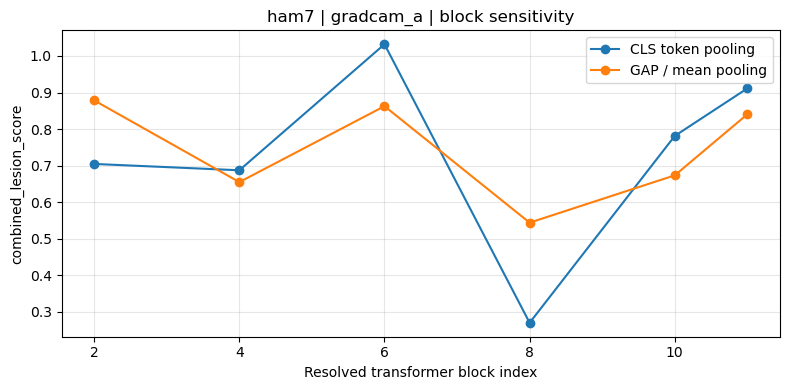

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/plot_block_sensitivity_ham7_gradcam_a_combined_lesion_score.png


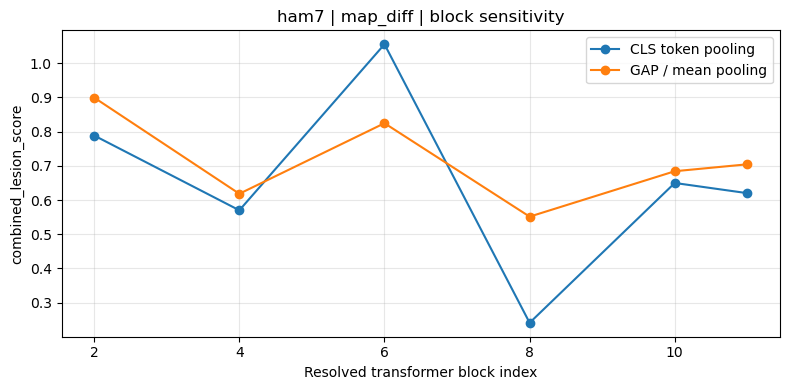

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/plot_block_sensitivity_ham7_map_diff_combined_lesion_score.png


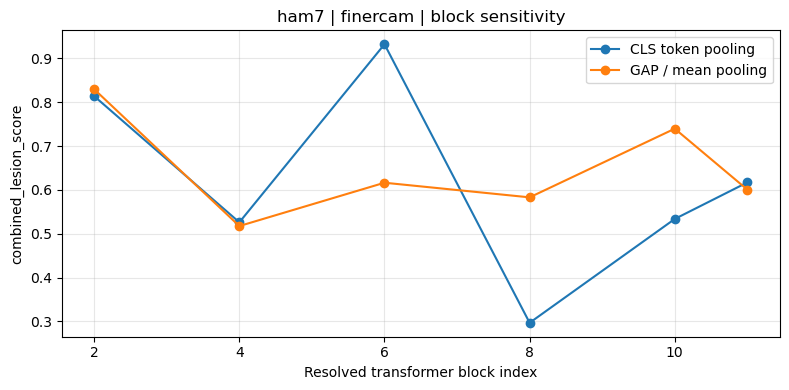

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/plot_block_sensitivity_ham7_finercam_combined_lesion_score.png


In [7]:
import matplotlib.pyplot as plt

def plot_block_sensitivity(task: str, cam_name: str, metric: str = "combined_lesion_score"):
    if "summary" not in globals() or len(summary) == 0:
        print("Run summary first.")
        return

    sub = summary[(summary["task"] == task) & (summary["cam_name"] == cam_name)].copy()
    if len(sub) == 0:
        print("No data for", task, cam_name)
        return

    plt.figure(figsize=(8, 4))
    for scenario, sdf in sub.groupby("scenario_name"):
        sdf = sdf.sort_values("resolved_block_index")
        plt.plot(
            sdf["resolved_block_index"],
            sdf[metric],
            marker="o",
            label=scenario,
        )

    plt.xlabel("Resolved transformer block index")
    plt.ylabel(metric)
    plt.title(f"{task} | {cam_name} | block sensitivity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out = OUT_ROOT / f"plot_block_sensitivity_{task}_{cam_name}_{metric}.png"
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


for task in ACTIVE_TASKS:
    for cam_name in CAM_NAMES:
        plot_block_sensitivity(task, cam_name, metric="combined_lesion_score")


## 6. Build PDF comparison for selected blocks

In [8]:
PANEL_SUFFIX = "rgb_gt_mask_gradcam_a_map_diff_finercam"


def get_font(size: int, bold: bool = False):
    candidates = [
        "/System/Library/Fonts/Supplemental/Arial Bold.ttf" if bold else "/System/Library/Fonts/Supplemental/Arial.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]
    for path in candidates:
        if path and Path(path).exists():
            return ImageFont.truetype(path, size=size)
    return ImageFont.load_default()


FONT_TITLE = get_font(34, bold=True)
FONT_SUBTITLE = get_font(22, bold=False)
FONT_LABEL = get_font(24, bold=True)
FONT_SMALL = get_font(18, bold=False)


def image_id_to_stem(image_id_value: str) -> str:
    p = Path(str(image_id_value))
    stem = p.stem if p.suffix else p.name
    return stem.replace("/", "_").replace("\\", "_").replace(" ", "_")


def find_panel_png(out_dir: Path, row: pd.Series) -> Path | None:
    candidates = []

    if "image_rel_path" in row and pd.notna(row["image_rel_path"]):
        candidates.append(image_id_to_stem(row["image_rel_path"]))
    if "image_id" in row and pd.notna(row["image_id"]):
        candidates.append(image_id_to_stem(row["image_id"]))
    if "image" in row and pd.notna(row["image"]):
        candidates.append(image_id_to_stem(row["image"]))

    for stem in dict.fromkeys(candidates):
        direct = out_dir / f"{stem}_{PANEL_SUFFIX}.png"
        if direct.exists():
            return direct
        matches = sorted(out_dir.glob(f"{stem}_*.png"))
        if matches:
            return matches[0]

    return None


def wrap_text(draw, text: str, font, max_width: int) -> list[str]:
    words = str(text).split()
    lines = []
    current = ""

    for word in words:
        test = f"{current} {word}".strip()
        bbox = draw.textbbox((0, 0), test, font=font)
        if bbox[2] - bbox[0] <= max_width:
            current = test
        else:
            if current:
                lines.append(current)
            current = word

    if current:
        lines.append(current)

    return lines


def make_pdf_page(row: pd.Series, task_name: str, task_cfg: dict, block_idx: int) -> Image.Image:
    page_width = 2200
    margin = 50
    label_width = 290
    gap = 18
    title_h = 120

    available_panel_width = page_width - 2 * margin - label_width - gap

    loaded_panels = []
    for scenario in task_cfg["scenarios"]:
        if not Path(scenario["checkpoint"]).exists():
            continue

        out_dir = scenario_out_dir(task_name, scenario, block_idx)
        panel_path = find_panel_png(out_dir, row)

        if panel_path is None:
            loaded_panels.append((scenario, None, None))
            continue

        panel = Image.open(panel_path).convert("RGB")
        scale = available_panel_width / panel.width
        new_h = int(panel.height * scale)
        panel = panel.resize((available_panel_width, new_h), Image.Resampling.LANCZOS)
        loaded_panels.append((scenario, panel, panel_path))

    row_heights = [panel.height if panel is not None else 260 for _, panel, _ in loaded_panels]
    page_height = title_h + margin + sum(row_heights) + gap * max(0, len(row_heights) - 1) + margin

    page = Image.new("RGB", (page_width, page_height), "white")
    draw = ImageDraw.Draw(page)

    image_id = row.get("image_id", row.get("image_rel_path", "unknown"))
    gt = row.get(task_cfg["gt_col"], row.get("gt_label", "unknown"))

    title = f"GAP vs CLS comparison: {image_id}"
    subtitle = f"Task: {task_name} | Ground truth: {gt} | Target block: {block_idx} (resolved {resolved_block_index(block_idx)})"

    draw.text((margin, 30), title, fill="black", font=FONT_TITLE)
    draw.text((margin, 78), subtitle, fill=(60, 60, 60), font=FONT_SUBTITLE)

    y = title_h
    for idx, (scenario, panel, panel_path) in enumerate(loaded_panels, start=1):
        row_h = row_heights[idx - 1]
        label = scenario["name"]

        label_lines = wrap_text(draw, label, FONT_LABEL, label_width - 10)
        label_x = margin
        label_y = y + 25

        for line in label_lines:
            draw.text((label_x, label_y), line, fill="black", font=FONT_LABEL)
            label_y += 32

        draw.text(
            (label_x, label_y + 10),
            f"Block {block_idx}",
            fill=(80, 80, 80),
            font=FONT_SMALL,
        )

        if panel is None:
            box_x = margin + label_width + gap
            box_y = y
            draw.rectangle([box_x, box_y, box_x + available_panel_width, box_y + row_h], outline=(180, 180, 180), width=2)
            draw.text((box_x + 30, box_y + 80), "Missing panel PNG", fill=(160, 0, 0), font=FONT_LABEL)
        else:
            page.paste(panel, (margin + label_width + gap, y))

        y += row_h + gap

    return page


def build_gap_vs_cls_pdf(task_name: str, task_cfg: dict, block_idx: int):
    df = load_csv_for_task(task_cfg)
    pages = []

    for _, row in df.iterrows():
        pages.append(make_pdf_page(row, task_name, task_cfg, block_idx))

    if not pages:
        print(f"[SKIP] No pages generated for {task_name}, block {block_idx}")
        return

    out_pdf = PDF_ROOT / f"gap_vs_cls_{task_name}_seed{QUAL_SEED}_block{block_idx}.pdf"
    pages[0].save(out_pdf, save_all=True, append_images=pages[1:], resolution=150.0)
    print("Saved PDF:", out_pdf)


if RUN_PDF_EXPORT:
    for task_name in ACTIVE_TASKS:
        task_cfg = TASK_CONFIGS[task_name]
        for block_idx in PDF_TARGET_BLOCKS:
            build_gap_vs_cls_pdf(task_name, task_cfg, block_idx)
else:
    print("RUN_PDF_EXPORT=False, skipping PDFs.")


Saved PDF: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/pdfs/gap_vs_cls_ham7_seed42_block-1.pdf
Saved PDF: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/gap_vs_cls_cam_comparison_seed42/pdfs/gap_vs_cls_ham7_seed42_block-4.pdf


## Interpretation template

Use this after you run the notebook:

- If CLS improves lesion energy and pointing game but reduces balanced accuracy/recall, report it as a tradeoff.
- If CLS only improves last-block visualization but not block `-4`, keep GAP + block `-4` as the main thesis setup.
- If GAP and CLS have similar localization, prefer the model with better balanced accuracy because the dataset is imbalanced.
- Do not choose a block only because of one pretty image. Choose it based on the ranked table and then use examples for illustration.
